In [2]:
 #Student Activity Performance Analysis

In [1]:
# Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import pearsonr

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
plt.style.use('ggplot')

In [3]:
#Load dataset


file_path = "data/Weekly Breakdown Merged.xlsx"

# Read the merged sheet
df = pd.read_excel(
    file_path,
    sheet_name="merged_data"
)

print("Dataset Loaded Successfully!")

print(f"\nRows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset Loaded Successfully!

Rows: 36
Columns: 120


In [4]:
# Preview the first five records

df.head(10)

,Attempt ID,User ID,First Name,Last Name,Mid-term Exam CEFR Level,Reading,Listening,Writing,Speaking,Final CEFR Level,Reading 2,Listening 2,Writing 2,Speaking 2,Hub Engagement Level (2/3),Overall,Reading2,Listening2,Writing2,Speaking2,Week1_a0_activities_completed_week,Week1_a0_activities_completed_total,Week1_a1_activities_completed_week,Week1_a1_activities_completed_total,Week1_a2_activities_completed_week,Week1_a2_activities_completed_total,Week1_b1_2_activities_completed_week,Week1_b1_2_activities_completed_total,Week1_numeracy_activities_completed_week,Week1_numeracy_activities_completed_total,Week2_a0_activities_completed_week,Week2_a0_activities_completed_total,Week2_a1_activities_completed_week,Week2_a1_activities_completed_total,Week2_a2_activities_completed_week,Week2_a2_activities_completed_total,Week2_b1_2_activities_completed_week,Week2_b1_2_activities_completed_total,Week2_numeracy_activities_completed_week,Week2_numeracy_activities_completed_total,Week3_a0_activities_completed_week,Week3_a0_activities_completed_total,Week3_a1_activities_completed_week,Week3_a1_activities_completed_total,Week3_a2_activities_completed_week,Week3_a2_activities_completed_total,Week3_b1_2_activities_completed_week,Week3_b1_2_activities_completed_total,Week3_numeracy_activities_completed_week,Week3_numeracy_activities_completed_total,Week4_a0_activities_completed_week,Week4_a0_activities_completed_total,Week4_a1_activities_completed_week,Week4_a1_activities_completed_total,Week4_a2_activities_completed_week,Week4_a2_activities_completed_total,Week4_b1_2_activities_completed_week,Week4_b1_2_activities_completed_total,Week4_numeracy_activities_completed_week,Week4_numeracy_activities_completed_total,Week5_a0_activities_completed_week,Week5_a0_activities_completed_total,Week5_a1_activities_completed_week,Week5_a1_activities_completed_total,Week5_a2_activities_completed_week,Week5_a2_activities_completed_total,Week5_b1_2_activities_completed_week,Week5_b1_2_activities_completed_total,Week5_numeracy_activities_completed_week,Week5_numeracy_activities_completed_total,Week6_a0_activities_completed_week,Week6_a0_activities_completed_total,Week6_a1_activities_completed_week,Week6_a1_activities_completed_total,Week6_a2_activities_completed_week,Week6_a2_activities_completed_total,Week6_b1_2_activities_completed_week,Week6_b1_2_activities_completed_total,Week6_numeracy_activities_completed_week,Week6_numeracy_activities_completed_total,Week7_a0_activities_completed_week,Week7_a0_activities_completed_total,Week7_a1_activities_completed_week,Week7_a1_activities_completed_total,Week7_a2_activities_completed_week,Week7_a2_activities_completed_total,Week7_b1_2_activities_completed_week,Week7_b1_2_activities_completed_total,Week7_numeracy_activities_completed_week,Week7_numeracy_activities_completed_total,Week8_a0_activities_completed_week,Week8_a0_activities_completed_total,Week8_a1_activities_completed_week,Week8_a1_activities_completed_total,Week8_a2_activities_completed_week,Week8_a2_activities_completed_total,Week8_b1_2_activities_completed_week,Week8_b1_2_activities_completed_total,Week8_numeracy_activities_completed_week,Week8_numeracy_activities_completed_total,Week9_a0_activities_completed_week,Week9_a0_activities_completed_total,Week9_a1_activities_completed_week,Week9_a1_activities_completed_total,Week9_a2_activities_completed_week,Week9_a2_activities_completed_total,Week9_b1_2_activities_completed_week,Week9_b1_2_activities_completed_total,Week9_numeracy_activities_completed_week,Week9_numeracy_activities_completed_total,Week10_a0_activities_completed_week,Week10_a0_activities_completed_total,Week10_a1_activities_completed_week,Week10_a1_activities_completed_total,Week10_a2_activities_completed_week,Week10_a2_activities_completed_total,Week10_b1_2_activities_completed_week,Week10_b1_2_activities_completed_total,Week10_numeracy_activities_completed_week,Week10_numeracy_activities_completed_total
0,NaN,11671,Andrea gombarova,NaN,1,Not Achiev

In [5]:
# View column names

df.columns.tolist()

['Attempt ID',
 'User ID',
 'First Name',
 'Last Name',
 'Mid-term Exam CEFR Level',
 'Reading',
 'Listening',
 'Writing',
 'Speaking',
 'Final CEFR Level',
 'Reading 2',
 'Listening 2',
 'Writing 2',
 'Speaking 2',
 'Hub Engagement Level (2/3)',
 'Overall',
 'Reading2',
 'Listening2',
 'Writing2',
 'Speaking2',
 'Week1_a0_activities_completed_week',
 'Week1_a0_activities_completed_total',
 'Week1_a1_activities_completed_week',
 'Week1_a1_activities_completed_total',
 'Week1_a2_activities_completed_week',
 'Week1_a2_activities_completed_total',
 'Week1_b1_2_activities_completed_week',
 'Week1_b1_2_activities_completed_total',
 'Week1_numeracy_activities_completed_week',
 'Week1_numeracy_activities_completed_total',
 'Week2_a0_activities_completed_week',
 'Week2_a0_activities_completed_total',
 'Week2_a1_activities_completed_week',
 'Week2_a1_activities_completed_total',
 'Week2_a2_activities_completed_week',
 'Week2_a2_activities_completed_total',
 'Week2_b1_2_activities_completed_week

In [6]:
# Check for missing values

missing = df.isnull().sum()

missing[missing > 0]

Attempt ID    36
Last Name      9
dtype: int64

In [7]:
# Data Cleaning

# Remove duplicate students based on User ID
df = df.drop_duplicates(subset="User ID")

# Replace missing numeric values with 0
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(0)

print("Duplicates Removed.")
print("Missing Numeric Values Filled.")

Duplicates Removed.
Missing Numeric Values Filled.


In [8]:
# Verify dataset shape after cleaning

print(df.shape)

(36, 120)


In [9]:
#Create Mid-Term and Final Assessment Totals

# Assessment Columns

mid_term_cols = [
    "Reading",
    "Listening",
    "Writing",
    "Speaking"
]

final_cols = [
    "Reading 2",
    "Listening 2",
    "Writing 2",
    "Speaking 2"
]

print("Mid-Term Columns:")
print(mid_term_cols)

print("\nFinal Assessment Columns:")
print(final_cols)


Mid-Term Columns:
['Reading', 'Listening', 'Writing', 'Speaking']

Final Assessment Columns:
['Reading 2', 'Listening 2', 'Writing 2', 'Speaking 2']


In [10]:
#Calculate Mid-Term and Final Total Scores


df[mid_term_cols].dtypes

# Convert Mid-Term columns to numeric
df[mid_term_cols] = df[mid_term_cols].apply(pd.to_numeric, errors='coerce')

# Convert Final columns to numeric
df[final_cols] = df[final_cols].apply(pd.to_numeric, errors='coerce')

df["Mid-Term Total"] = df[mid_term_cols].sum(axis=1, skipna=True)

df["Final Total"] = df[final_cols].sum(axis=1, skipna=True)

df[["User ID", "Mid-Term Total", "Final Total"]].head()

,User ID,Mid-Term Total,Final Total
0,11671,2.0,3.0
1,11779,0.0,7.0
2,11973,4.0,5.0
3,11996,3.0,5.0
4,12009,7.0,12.0


In [11]:
#Calculate Improvement Score


df["Improvement Score"] = (
    df["Final Total"] -
    df["Mid-Term Total"]
)

df[["User ID","Improvement Score"]].head()


,User ID,Improvement Score
0,11671,1.0
1,11779,7.0
2,11973,1.0
3,11996,2.0
4,12009,5.0


In [12]:
# Percentage Improvement


df["Improvement %"] = np.where(
    df["Mid-Term Total"] == 0,
    np.nan,
    ((df["Final Total"] - df["Mid-Term Total"])
      / df["Mid-Term Total"]) * 100
)

df[["User ID","Improvement %"]].head()

,User ID,Improvement %
0,11671,50.000000
1,11779,NaN
2,11973,25.000000
3,11996,66.666667
4,12009,71.428571


In [13]:
#Classify Student Performance


def improvement_category(score):
    
    if score > 0:
        return "Improved"
    
    elif score < 0:
        return "Declined"
    
    else:
        return "No Change"

df["Performance Category"] = df["Improvement Score"].apply(improvement_category)

df["Performance Category"].value_counts()

Improved     29
No Change     6
Declined      1
Name: Performance Category, dtype: int64

In [14]:
#Summary Statistics


summary = df[
    [
        "Mid-Term Total",
        "Final Total",
        "Improvement Score",
        "Improvement %"
    ]
].describe()

summary

,Mid-Term Total,Final Total,Improvement Score,Improvement %
count,36.000000,36.000000,36.000000,34.000000
mean,5.500000,7.638889,2.138889,64.995438
std,3.264528,3.062704,2.002181,116.766192
min,0.000000,2.000000,-1.000000,-33.333333
25%,3.000000,6.000000,1.000000,10.625000
50%,6.000000,7.000000,2.000000,37.500000
75%,7.250000,11.000000,3.250000,65.000000
max,12.000000,12.000000,7.000000,600.000000


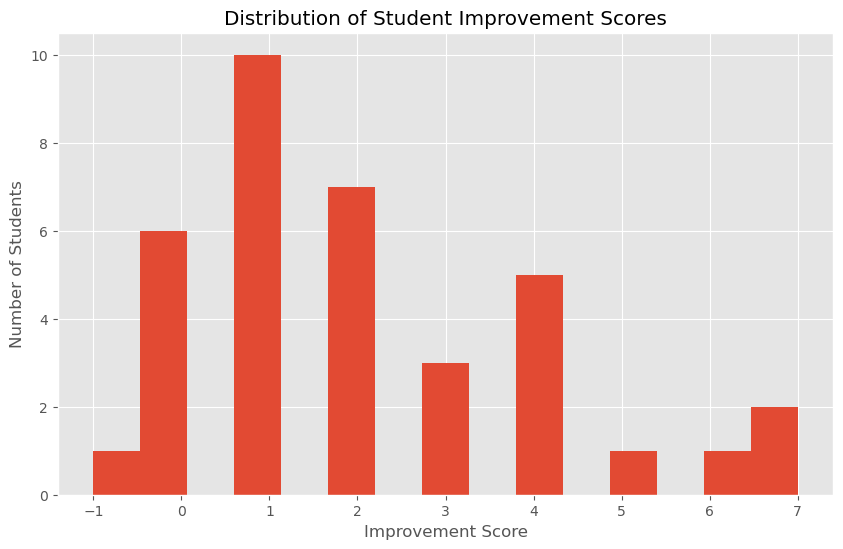

In [15]:
#Visualize Improvement Distribution


plt.figure(figsize=(10,6))

plt.hist(df["Improvement Score"], bins=15)

plt.title("Distribution of Student Improvement Scores")

plt.xlabel("Improvement Score")

plt.ylabel("Number of Students")

plt.show()

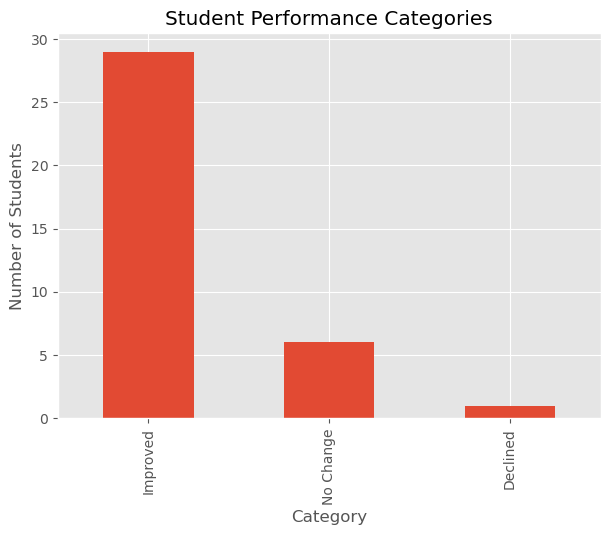

In [16]:
#Count Students by Performance Category

plt.figure(figsize=(7,5))

df["Performance Category"].value_counts().plot(kind="bar")

plt.title("Student Performance Categories")

plt.xlabel("Category")

plt.ylabel("Number of Students")

plt.show()

In [17]:
#Display Student Improvement Table

student_improvement = df[
    [
        "User ID",
        "First Name",
        "Last Name",
        "Mid-Term Total",
        "Final Total",
        "Improvement Score",
        "Improvement %",
        "Performance Category"
    ]
]

student_improvement.head(10)

,User ID,First Name,Last Name,Mid-Term Total,Final Total,Improvement Score,Improvement %,Performance Category
0,11671,Andrea gombarova,NaN,2.0,3.0,1.0,50.000000,Improved
1,11779,Mary Erinda Anton Jeganathan,NaN,0.0,7.0,7.0,NaN,Improved
2,11973,Zlatica Curejova,NaN,4.0,5.0,1.0,25.000000,Improved
3,11996,Al-Shemari Mohamed,DUP?,3.0,5.0,2.0,66.666667,Improved
4,12009,asmaa,al mansori,7.0,12.0,5.0,71.428571,Improved
5,12019,Nebris,Abdullah,1.0,7.0,6.0,600.000000,Improved
6,12031,Belayneshe Mente,NaN,7.0,7.0,0.0,0.000000,No Change
7,12064,Bianca-Simina,Gabrian,9.0,11.0,2.0,22.222222,Improved
8,12065,Biniyam,Solomon,9.0,11.0,2.0,22.222222,Improved
9,12080,Jamal Hassan,NaN,4.0,6.0,2.0,50.000000,Improved


In [18]:
#Weekly Activity Feature Engineering

week_cols = [col for col in df.columns if "week" in col.lower()]
week_cols

['Week1_a0_activities_completed_week',
 'Week1_a0_activities_completed_total',
 'Week1_a1_activities_completed_week',
 'Week1_a1_activities_completed_total',
 'Week1_a2_activities_completed_week',
 'Week1_a2_activities_completed_total',
 'Week1_b1_2_activities_completed_week',
 'Week1_b1_2_activities_completed_total',
 'Week1_numeracy_activities_completed_week',
 'Week1_numeracy_activities_completed_total',
 'Week2_a0_activities_completed_week',
 'Week2_a0_activities_completed_total',
 'Week2_a1_activities_completed_week',
 'Week2_a1_activities_completed_total',
 'Week2_a2_activities_completed_week',
 'Week2_a2_activities_completed_total',
 'Week2_b1_2_activities_completed_week',
 'Week2_b1_2_activities_completed_total',
 'Week2_numeracy_activities_completed_week',
 'Week2_numeracy_activities_completed_total',
 'Week3_a0_activities_completed_week',
 'Week3_a0_activities_completed_total',
 'Week3_a1_activities_completed_week',
 'Week3_a1_activities_completed_total',
 'Week3_a2_activitie

In [19]:
#Clean Column Names

df.columns = df.columns.str.strip()

#Convert Week Columns to Numeric
for col in week_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

#Total Activities Across All Weeks
df["Total_Activities"] = df[week_cols].sum(axis=1)

#Average Weekly Activity
df["Avg_Weekly_Activity"] = df[week_cols].mean(axis=1)

# A Quick Check
df[["User ID", "Total_Activities", "Avg_Weekly_Activity"]].head()

,User ID,Total_Activities,Avg_Weekly_Activity
0,11671,7891,78.91
1,11779,79,0.79
2,11973,4663,46.63
3,11996,3866,38.66
4,12009,2261,22.61


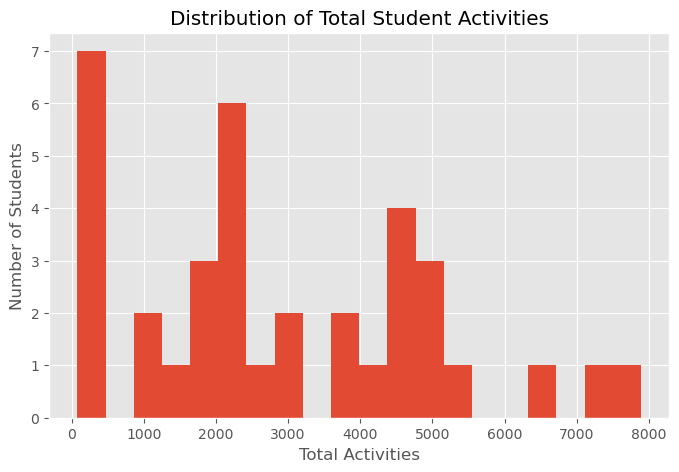

In [20]:
#Distribution of Total Activities by Students

plt.figure(figsize=(8,5))
plt.hist(df["Total_Activities"], bins=20)
plt.title("Distribution of Total Student Activities")
plt.xlabel("Total Activities")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()

In [21]:
#Standardise Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#Identify Exam Columns
[col for col in df.columns if "mid" in col or "final" in col or "exam" in col]

#Convert Exam Columns to Numeric
exam_cols = [col for col in df.columns if "mid" in col or "final" in col or "exam" in col]

for col in exam_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


#Correlation Matrix
correlation_data = df[["total_activities", "avg_weekly_activity"] + exam_cols]

correlation_matrix = correlation_data.corr()

correlation_matrix

,total_activities,avg_weekly_activity,mid-term_exam_cefr_level,final_cefr_level,mid-term_total,final_total
total_activities,1.000000,1.000000,0.184701,0.296381,0.155306,0.115654
avg_weekly_activity,1.000000,1.000000,0.184701,0.296381,0.155306,0.115654
mid-term_exam_cefr_level,0.184701,0.184701,1.000000,0.831163,0.939372,0.796152
final_cefr_level,0.296381,0.296381,0.831163,1.000000,0.841317,0.891139
mid-term_total,0.155306,0.155306,0.939372,0.841317,1.000000,0.801566
final_total,0.115654,0.115654,0.796152,0.891139,0.801566,1.000000


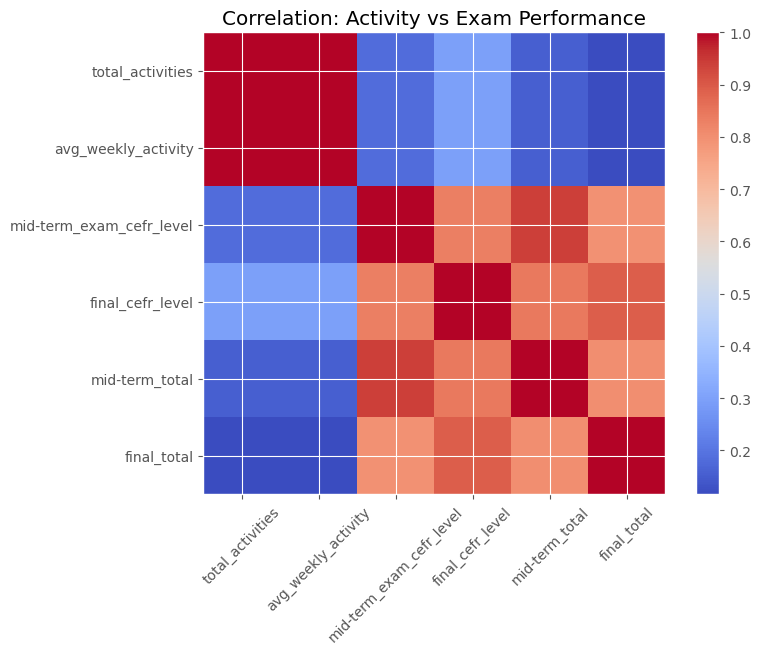

In [22]:
#Visualise Correlation (Heatmap)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation: Activity vs Exam Performance")
plt.show()

In [24]:
#Interpretation Output

df[["total_activities", "avg_weekly_activity"] + exam_cols].corr()["total_activities"]

total_activities            1.000000
avg_weekly_activity         1.000000
mid-term_exam_cefr_level    0.184701
final_cefr_level            0.296381
mid-term_total              0.155306
final_total                 0.115654
Name: total_activities, dtype: float64

In [23]:
# Create a copy for modeling
df_model = df.copy()

# Make sure column names are consistent
df_model.columns = df_model.columns.str.strip().str.lower().str.replace(" ", "_")

# Create binary target:
# 1 = Improved
# 0 = Did not improve
df_model["improved_flag"] = np.where(
    df_model["final_total"] > df_model["mid-term_total"],
    1,
    0
)

df_model["improved_flag"].value_counts()

1    29
0     7
Name: improved_flag, dtype: int64

In [24]:
feature_cols = [
    "reading",
    "listening",
    "writing",
    "speaking",
    "mid-term_total",
    "total_activities",
    "avg_weekly_activity"
]

# Keep only columns that exist in the dataset
feature_cols = [col for col in feature_cols if col in df_model.columns]

X = df_model[feature_cols].fillna(0)
y = df_model["improved_flag"]

X.head()

,reading,listening,writing,speaking,mid-term_total,total_activities,avg_weekly_activity
0,0.0,1.0,0.0,1.0,2.0,7891,78.91
1,0.0,0.0,0.0,0.0,0.0,79,0.79
2,0.0,2.0,1.0,1.0,4.0,4663,46.63
3,1.0,2.0,0.0,0.0,3.0,3866,38.66
4,2.0,2.0,2.0,1.0,7.0,2261,22.61


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Build model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
])

# Train model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5555555555555556
Balanced Accuracy: 0.5357142857142857

Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.50      0.33         2
           1       0.80      0.57      0.67         7

    accuracy                           0.56         9
   macro avg       0.53      0.54      0.50         9
weighted avg       0.68      0.56      0.59         9



Repeated stratified cross-validation

In [27]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=50,
    random_state=42
)

scores = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
    return_train_score=True
)

results = pd.DataFrame(scores)

print("Average Accuracy:", results["test_accuracy"].mean())
print("Average Balanced Accuracy:", results["test_balanced_accuracy"].mean())
print("Average F1:", results["test_f1"].mean())

print("\nScore Stability:")
print(results[["test_accuracy", "test_balanced_accuracy", "test_f1"]].describe())

Average Accuracy: 0.6453571428571431
Average Balanced Accuracy: 0.6337333333333333
Average F1: 0.7357301365301365

Score Stability:
       test_accuracy  test_balanced_accuracy     test_f1
count     250.000000              250.000000  250.000000
mean        0.645357                0.633733    0.735730
std         0.160735                0.222371    0.141220
min         0.142857                0.083333    0.250000
25%         0.571429                0.416667    0.666667
50%         0.625000                0.666667    0.727273
75%         0.714286                0.833333    0.800000
max         1.000000                1.000000    1.000000


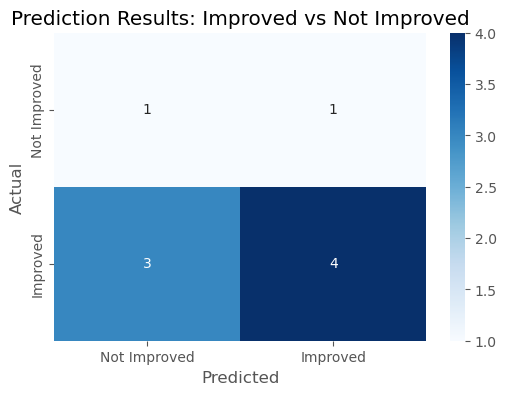

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Improved", "Improved"],
    yticklabels=["Not Improved", "Improved"]
)

plt.title("Prediction Results: Improved vs Not Improved")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Baseline model
The model was compared against a simple baseline that assumes every student improves. This prevents us from overstating performance in a small, imbalanced dataset.

In [28]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

baseline = Pipeline([
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline_scores = cross_validate(
    baseline,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "f1"]
)

print("Baseline Accuracy:", baseline_scores["test_accuracy"].mean())
print("Baseline Balanced Accuracy:", baseline_scores["test_balanced_accuracy"].mean())
print("Baseline F1:", baseline_scores["test_f1"].mean())

Baseline Accuracy: 0.8071428571428572
Baseline Balanced Accuracy: 0.5
Baseline F1: 0.8919413919413921


In [29]:
print("Model Balanced Accuracy:", results["test_balanced_accuracy"].mean())
print("Baseline Balanced Accuracy:", baseline_scores["test_balanced_accuracy"].mean())

Model Balanced Accuracy: 0.6337333333333333
Baseline Balanced Accuracy: 0.5


In [30]:
# Stratified Cross-Validation + Ridge Logistic Regression
# Ridge Logistic Regression = Logistic Regression with L2 regularisation

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
import pandas as pd
import numpy as np

# ----------------------------------------------------
# 1. Check class balance
# ----------------------------------------------------

print("Class balance:")
print(y.value_counts())
print("\nClass balance percentage:")
print(y.value_counts(normalize=True))

# ----------------------------------------------------
# 2. Build Ridge Logistic Regression model
# ----------------------------------------------------

ridge_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        penalty="l2",              # Ridge regularisation
        C=0.5,                     # Smaller C = stronger regularisation
        class_weight="balanced",   # Helps with imbalance: 29 improved vs 7 not improved
        max_iter=1000,
        random_state=42
    ))
])

# ----------------------------------------------------
# 3. Build simple baseline model
# ----------------------------------------------------
# This predicts the most common class only.
# It helps check whether our model is actually useful.

baseline_model = Pipeline([
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

# ----------------------------------------------------
# 4. Repeated Stratified Cross-Validation
# ----------------------------------------------------
# n_splits=5 works because the smaller class has around 7 students.
# n_repeats=50 gives a more stable estimate.

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=50,
    random_state=42
)

# Custom scorers to avoid errors when a fold has difficult predictions
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

# ----------------------------------------------------
# 5. Evaluate Ridge Logistic Regression
# ----------------------------------------------------

ridge_scores = cross_validate(
    ridge_logistic_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# ----------------------------------------------------
# 6. Evaluate baseline model
# ----------------------------------------------------

baseline_scores = cross_validate(
    baseline_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# ----------------------------------------------------
# 7. Summarise results
# ----------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Ridge Logistic Regression": [
        ridge_scores["test_accuracy"].mean(),
        ridge_scores["test_balanced_accuracy"].mean(),
        ridge_scores["test_precision"].mean(),
        ridge_scores["test_recall"].mean(),
        ridge_scores["test_f1"].mean()
    ],
    "Baseline Model": [
        baseline_scores["test_accuracy"].mean(),
        baseline_scores["test_balanced_accuracy"].mean(),
        baseline_scores["test_precision"].mean(),
        baseline_scores["test_recall"].mean(),
        baseline_scores["test_f1"].mean()
    ]
})

display(summary)

# ----------------------------------------------------
# 8. Show score stability
# ----------------------------------------------------

stability = pd.DataFrame({
    "Balanced Accuracy": ridge_scores["test_balanced_accuracy"],
    "F1 Score": ridge_scores["test_f1"]
})

print("\nRidge Logistic Regression score stability:")
display(stability.describe())

# ----------------------------------------------------
# 9. Fit final model on all data to inspect feature influence
# ----------------------------------------------------

ridge_logistic_model.fit(X, y)

coefficients = ridge_logistic_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature influence from final model:")
display(feature_importance)

Class balance:
1    29
0     7
Name: improved_flag, dtype: int64

Class balance percentage:
1    0.805556
0    0.194444
Name: improved_flag, dtype: float64


,Metric,Ridge Logistic Regression,Baseline Model
0,Accuracy,0.639357,0.807143
1,Balanced Accuracy,0.625267,0.500000
2,Precision,0.877486,0.807143
3,Recall,0.654533,1.000000
4,F1 Score,0.731518,0.891941



Ridge Logistic Regression score stability:


,Balanced Accuracy,F1 Score
count,250.000000,250.000000
mean,0.625267,0.731518
std,0.226783,0.144492
min,0.083333,0.250000
25%,0.416667,0.666667
50%,0.666667,0.727273
75%,0.833333,0.800000
max,1.000000,1.000000



Feature influence from final model:


,Feature,Coefficient
2,writing,0.495945
0,reading,-0.078740
5,total_activities,-0.084334
6,avg_weekly_activity,-0.084334
1,listening,-0.091639
4,mid-term_total,-0.202828
3,speaking,-1.068205
